In [ ]:
import pandas as pd
import numpy as np

In [1]:
import pandas as pd

In [5]:
genotype = pd.read_csv('C:\Malaria_frequencies\Important_genotype.csv')

In [6]:
genotype.head()

,Unnamed: 0,Sample,crt_76[K],dhfr_108[S],dhps_437[G],dhfr_51[N]_assoc,dhfr_59[C]_assoc,dhfr_164[I]_assoc,dhps_540[K]_assoc,dhps_581[A]_assoc,dhps_613[A]_assoc,kelch13_known,mdr1_dup_call,pm2_dup_call
0,0,FP0008-C,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive
1,1,FP0009-C,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive
2,2,FP0010-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive
3,3,FP0011-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive
4,4,FP0012-CW,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive


In [8]:
genotype['dhps_540[K]_assoc'].value_counts()

dhps_540[K]_assoc
Sensitive    12850
Resistant     8386
Other         2810
Missing        363
Name: count, dtype: int64

In [9]:
genotype['mdr1_dup_call'].value_counts()

mdr1_dup_call
Sensitive    19512
rare          4195
Resistant      702
Name: count, dtype: int64

In [10]:
genotype['crt_76[K]'].value_counts()

crt_76[K]
Resistant    13593
Sensitive    10768
Missing         48
Name: count, dtype: int64

In [11]:
# Show the names of all columns in the genotype table
genotype.columns.tolist()

['Unnamed: 0',
 'Sample',
 'crt_76[K]',
 'dhfr_108[S]',
 'dhps_437[G]',
 'dhfr_51[N]_assoc',
 'dhfr_59[C]_assoc',
 'dhfr_164[I]_assoc',
 'dhps_540[K]_assoc',
 'dhps_581[A]_assoc',
 'dhps_613[A]_assoc',
 'kelch13_known',
 'mdr1_dup_call',
 'pm2_dup_call']

In [12]:
# Load the sample-information table
samples = pd.read_csv("Pf8-samples.csv")

# Show the first five sample IDs in each table
print("Genotype sample IDs:")
print(genotype["Sample"].head().tolist())

print("\nSample-information IDs:")
print(samples["sample_id"].head().tolist())

# Check how many genotype samples can be found in the sample-information table
match_rate = genotype["Sample"].isin(samples["sample_id"]).mean()

print(f"\nMatch rate: {match_rate:.1%}")

Genotype sample IDs:
['FP0008-C', 'FP0009-C', 'FP0010-CW', 'FP0011-CW', 'FP0012-CW']

Sample-information IDs:
['FP0008-C', 'FP0009-C', 'FP0010-CW', 'FP0011-CW', 'FP0012-CW']

Match rate: 100.0%


In [13]:
# List of African country codes found in this dataset
african_country_codes = [
    "BF", "BJ", "CD", "CI", "CM", "ET", "GA", "GH", "GM", "GN",
    "KE", "MG", "ML", "MR", "MW", "MZ", "NG", "SD", "SN", "TZ", "UG"
]

# Keep only samples that passed quality control and come from Africa
africa_samples = samples[
    (samples["qc_pass"].astype(str).str.lower() == "true") &
    (samples["country_id"].isin(african_country_codes))
].copy()

# Attach the genotype-marker information to those African samples
africa_genotype = genotype.merge(
    africa_samples[["sample_id", "country", "country_id"]],
    left_on="Sample",
    right_on="sample_id",
    how="inner"
)

# Check the result
print("QC-passing African samples:", len(africa_genotype))
print("\nFirst five rows:")
africa_genotype.head()

QC-passing African samples: 14508

First five rows:


,Unnamed: 0,Sample,crt_76[K],dhfr_108[S],dhps_437[G],dhfr_51[N]_assoc,dhfr_59[C]_assoc,dhfr_164[I]_assoc,dhps_540[K]_assoc,dhps_581[A]_assoc,dhps_613[A]_assoc,kelch13_known,mdr1_dup_call,pm2_dup_call,sample_id,country,country_id
0,0,FP0008-C,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive,FP0008-C,Mauritania,MR
1,1,FP0009-C,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive,FP0009-C,Mauritania,MR
2,2,FP0010-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive,FP0010-CW,Mauritania,MR
3,3,FP0011-CW,Resistant,Resistant,Resistant,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive,FP0011-CW,Mauritania,MR
4,4,FP0012-CW,Resistant,Resistant,Sensitive,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Missing,Sensitive,Sensitive,FP0012-CW,Mauritania,MR


In [14]:
# These are the genomic resistance markers for Objective 1
markers = [
    "crt_76[K]",
    "dhfr_108[S]",
    "dhps_437[G]",
    "dhfr_51[N]_assoc",
    "dhfr_59[C]_assoc",
    "dhfr_164[I]_assoc",
    "dhps_540[K]_assoc",
    "dhps_581[A]_assoc",
    "dhps_613[A]_assoc",
    "kelch13_known",
    "mdr1_dup_call",
    "pm2_dup_call"
]

# Count each possible call for every marker
for marker in markers:
    print("\n" + "=" * 45)
    print(marker)
    print(africa_genotype[marker].value_counts(dropna=False))


crt_76[K]
crt_76[K]
Sensitive    10295
Resistant     4198
Missing         15
Name: count, dtype: int64

dhfr_108[S]
dhfr_108[S]
Resistant    13160
Sensitive     1033
Missing        315
Name: count, dtype: int64

dhps_437[G]
dhps_437[G]
Resistant    12164
Sensitive     2146
Missing        198
Name: count, dtype: int64

dhfr_51[N]_assoc
dhfr_51[N]_assoc
Resistant    12488
Sensitive     1791
Missing        229
Name: count, dtype: int64

dhfr_59[C]_assoc
dhfr_59[C]_assoc
Resistant    12605
Sensitive     1658
Missing        244
Other            1
Name: count, dtype: int64

dhfr_164[I]_assoc
dhfr_164[I]_assoc
Sensitive    14325
Missing        159
Resistant       22
Other            2
Name: count, dtype: int64

dhps_540[K]_assoc
dhps_540[K]_assoc
Sensitive    10247
Resistant     4040
Missing        221
Name: count, dtype: int64

dhps_581[A]_assoc
dhps_581[A]_assoc
Sensitive    13625
Resistant      657
Missing        226
Name: count, dtype: int64

dhps_613[A]_assoc
dhps_613[A]_assoc
Sensitive

In [15]:
# Friendly labels for the table you will present
marker_labels = {
    "crt_76[K]": "pfcrt 76 (chloroquine)",
    "dhfr_108[S]": "dhfr 108 (pyrimethamine)",
    "dhps_437[G]": "dhps 437 (sulfadoxine)",
    "dhfr_51[N]_assoc": "dhfr 51 (pyrimethamine)",
    "dhfr_59[C]_assoc": "dhfr 59 (pyrimethamine)",
    "dhfr_164[I]_assoc": "dhfr 164 (pyrimethamine)",
    "dhps_540[K]_assoc": "dhps 540 (sulfadoxine)",
    "dhps_581[A]_assoc": "dhps 581 (sulfadoxine)",
    "dhps_613[A]_assoc": "dhps 613 (sulfadoxine)",
    "kelch13_known": "kelch13 known (artemisinin)",
    "mdr1_dup_call": "mdr1 duplication (mefloquine)",
    "pm2_dup_call": "pm2 duplication (piperaquine)"
}

# Build the Objective 1 results table
results = []

for marker in markers:
    calls = africa_genotype[marker].fillna("Missing").value_counts()

    resistant = calls.get("Resistant", 0)
    sensitive = calls.get("Sensitive", 0)
    missing = calls.get("Missing", 0)
    rare = calls.get("rare", 0)

    called = resistant + sensitive
    frequency = resistant / called if called > 0 else None

    results.append({
        "Marker": marker_labels[marker],
        "Resistant": resistant,
        "Sensitive": sensitive,
        "Callable samples": called,
        "Missing": missing,
        "Rare": rare,
        "Resistance frequency": frequency
    })

objective1_table = pd.DataFrame(results)

# Make the frequency easy to read as a percentage
objective1_table["Resistance frequency (%)"] = (
    objective1_table["Resistance frequency"] * 100
).round(1)

# Show the final Objective 1 table
objective1_table

,Marker,Resistant,Sensitive,Callable samples,Missing,Rare,Resistance frequency,Resistance frequency (%)
0,pfcrt 76 (chloroquine),4198,10295,14493,15,0,0.289657,29.0
1,dhfr 108 (pyrimethamine),13160,1033,14193,315,0,0.927218,92.7
2,dhps 437 (sulfadoxine),12164,2146,14310,198,0,0.850035,85.0
3,dhfr 51 (pyrimethamine),12488,1791,14279,229,0,0.874571,87.5
4,dhfr 59 (pyrimethamine),12605,1658,14263,244,0,0.883755,88.4
5,dhfr 164 (pyrimethamine),22,14325,14347,159,0,0.001533,0.2
6,dhps 540 (sulfadoxine),4040,10247,14287,221,0,0.282775,28.3
7,dhps 581 (sulfadoxine),657,13625,14282,226,0,0.046002,4.6
8,dhps 613 (sulfadoxine),1227,13061,14288,219,0,0.085876,8.6
9,kelch13 known (artemisinin),1,0,1,14217,0,1.000000,100.0


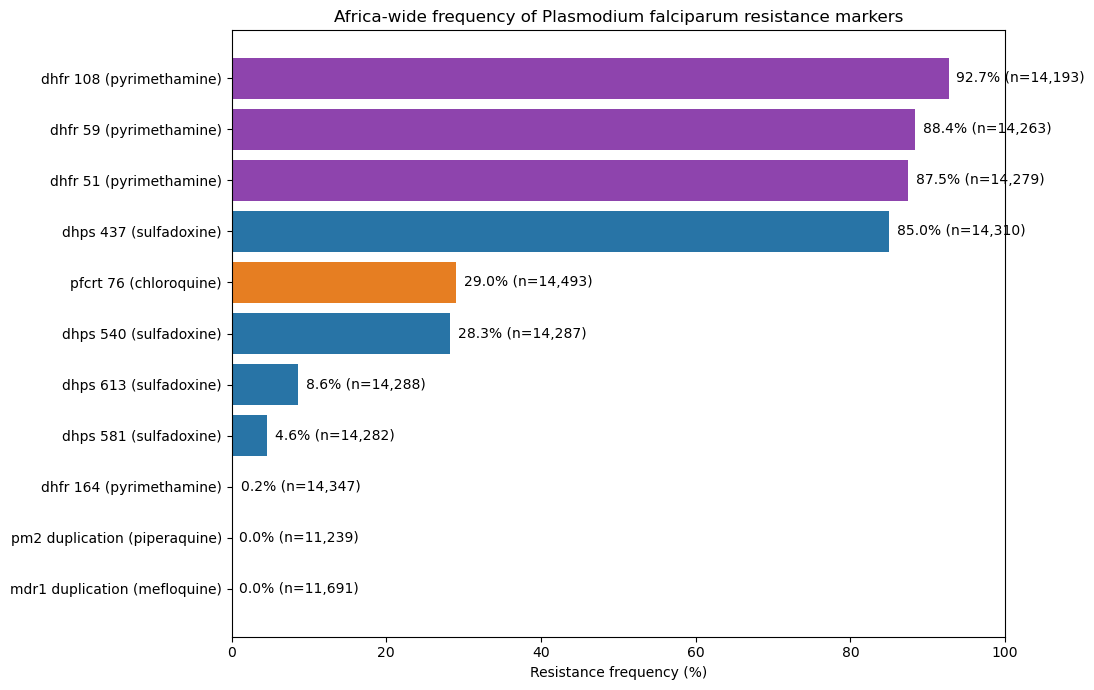

In [16]:
import matplotlib.pyplot as plt

# Keep only markers with enough usable observations for the main figure
# We use at least 100 callable samples as a simple reliability rule.
plot_table = objective1_table[
    objective1_table["Callable samples"] >= 100
].copy()

# Give each drug group a colour
plot_table["Drug group"] = [
    "Chloroquine" if "chloroquine" in marker else
    "Pyrimethamine" if "pyrimethamine" in marker else
    "Sulfadoxine" if "sulfadoxine" in marker else
    "Mefloquine" if "mefloquine" in marker else
    "Piperaquine"
    for marker in plot_table["Marker"]
]

colours = {
    "Chloroquine": "#E67E22",
    "Pyrimethamine": "#8E44AD",
    "Sulfadoxine": "#2874A6",
    "Mefloquine": "#239B56",
    "Piperaquine": "#17A589"
}

# Sort bars from low to high frequency
plot_table = plot_table.sort_values("Resistance frequency (%)")

# Create the chart
plt.figure(figsize=(11, 7))

bars = plt.barh(
    plot_table["Marker"],
    plot_table["Resistance frequency (%)"],
    color=[colours[group] for group in plot_table["Drug group"]]
)

plt.title("Africa-wide frequency of Plasmodium falciparum resistance markers")
plt.xlabel("Resistance frequency (%)")
plt.xlim(0, 100)

# Add frequency and sample size to every bar
for bar, (_, row) in zip(bars, plot_table.iterrows()):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{row["Resistance frequency (%)"]}% (n={row["Callable samples"]:,})',
        va="center"
    )

plt.tight_layout()

# Save a high-quality image for your report or PowerPoint
plt.savefig("objective1_africawide_resistance_chart.png", dpi=300)

plt.show()

In [17]:
objective1_table.to_csv(
    "objective1_africawide_marker_results.csv",
    index=False
)

print("Results table saved successfully.")

Results table saved successfully.


In [18]:
total_african_samples = len(africa_genotype)

objective1_table["Call rate (%)"] = (
    objective1_table["Callable samples"] / total_african_samples * 100
).round(1)

objective1_table[
    ["Marker", "Callable samples", "Missing", "Rare",
     "Call rate (%)", "Resistance frequency (%)"]
]

,Marker,Callable samples,Missing,Rare,Call rate (%),Resistance frequency (%)
0,pfcrt 76 (chloroquine),14493,15,0,99.9,29.0
1,dhfr 108 (pyrimethamine),14193,315,0,97.8,92.7
2,dhps 437 (sulfadoxine),14310,198,0,98.6,85.0
3,dhfr 51 (pyrimethamine),14279,229,0,98.4,87.5
4,dhfr 59 (pyrimethamine),14263,244,0,98.3,88.4
5,dhfr 164 (pyrimethamine),14347,159,0,98.9,0.2
6,dhps 540 (sulfadoxine),14287,221,0,98.5,28.3
7,dhps 581 (sulfadoxine),14282,226,0,98.4,4.6
8,dhps 613 (sulfadoxine),14288,219,0,98.5,8.6
9,kelch13 known (artemisinin),1,14217,0,0.0,100.0


In [19]:
objective1_table.to_csv(
    "objective1_africawide_marker_results.csv",
    index=False
)

In [20]:
# Add each sample's collection year to the African genotype table
africa_time = africa_genotype.merge(
    samples[["sample_id", "year"]],
    on="sample_id",
    how="left",
    validate="many_to_one"
)

# Make sure year is treated as a number
africa_time["year"] = pd.to_numeric(africa_time["year"], errors="coerce")

# Count samples in each year
year_counts = africa_time["year"].value_counts().sort_index()

print("Number of African samples:", len(africa_time))
print("Samples with no year:", africa_time["year"].isna().sum())
print("First year:", int(year_counts.index.min()))
print("Last year:", int(year_counts.index.max()))

# Show the number of samples collected in every year
year_counts.to_frame(name="Number of samples")

Number of African samples: 14508
Samples with no year: 0
First year: 1966
Last year: 2022


,Number of samples
year,
1966,7
1967,7
1968,12
1969,13
1970,15
1971,1
1984,137
1990,10
1991,2


In [21]:
# Put each sample into a five-year time period
africa_time["period_start"] = (
    africa_time["year"] // 5 * 5
).astype("Int64")

africa_time["five_year_period"] = africa_time["period_start"].apply(
    lambda year: f"{int(year)}–{int(year) + 4}" if pd.notna(year) else "Unknown"
)

# Count the number of samples in each five-year period
period_counts = (
    africa_time["five_year_period"]
    .value_counts()
    .sort_index()
    .to_frame(name="Number of samples")
)

# Mark periods with enough samples for interpretation
period_counts["Use for trend analysis?"] = (
    period_counts["Number of samples"] >= 100
)

period_counts

,Number of samples,Use for trend analysis?
five_year_period,,
1965–1969,39,False
1970–1974,16,False
1980–1984,137,True
1990–1994,65,False
1995–1999,259,True
2000–2004,173,True
2005–2009,685,True
2010–2014,4410,True
2015–2019,7420,True


In [22]:
# Create transparent African subregion labels from country codes
subregion_map = {
    # West Africa
    "BF": "West Africa",
    "BJ": "West Africa",
    "CI": "West Africa",
    "GH": "West Africa",
    "GM": "West Africa",
    "GN": "West Africa",
    "ML": "West Africa",
    "MR": "West Africa",
    "NG": "West Africa",
    "SN": "West Africa",

    # Central Africa
    "CD": "Central Africa",
    "CM": "Central Africa",
    "GA": "Central Africa",

    # East Africa
    "ET": "East Africa",
    "KE": "East Africa",
    "SD": "East Africa",
    "TZ": "East Africa",
    "UG": "East Africa",

    # Southern Africa
    "MG": "Southern Africa",
    "MW": "Southern Africa",
    "MZ": "Southern Africa"
}

# Add the subregion to every African sample
africa_time["subregion"] = africa_time["country_id"].map(subregion_map)

# Check how many samples are in each subregion
subregion_counts = (
    africa_time["subregion"]
    .value_counts()
    .to_frame(name="Number of samples")
)

print("Samples without a subregion:", africa_time["subregion"].isna().sum())

subregion_counts

Samples without a subregion: 0


,Number of samples
subregion,
West Africa,8598
East Africa,3106
Central Africa,1528
Southern Africa,1276


In [23]:
# Calculate resistance frequency for every marker in every subregion
regional_results = []

for subregion, group in africa_time.groupby("subregion"):
    for marker in markers:
        calls = group[marker].fillna("Missing").value_counts()

        resistant = calls.get("Resistant", 0)
        sensitive = calls.get("Sensitive", 0)
        missing = calls.get("Missing", 0)
        rare = calls.get("rare", 0)

        callable_samples = resistant + sensitive

        # Only calculate a percentage when we have enough usable calls
        if callable_samples >= 30:
            frequency = resistant / callable_samples * 100
        else:
            frequency = None

        regional_results.append({
            "Subregion": subregion,
            "Marker": marker_labels[marker],
            "Resistant": resistant,
            "Sensitive": sensitive,
            "Callable samples": callable_samples,
            "Missing": missing,
            "Rare": rare,
            "Resistance frequency (%)": frequency
        })

regional_table = pd.DataFrame(regional_results)

# Create a compact table: one row per subregion, one column per marker
regional_frequency_table = regional_table.pivot(
    index="Subregion",
    columns="Marker",
    values="Resistance frequency (%)"
).round(1)

regional_frequency_table

Marker,dhfr 108 (pyrimethamine),dhfr 164 (pyrimethamine),dhfr 51 (pyrimethamine),dhfr 59 (pyrimethamine),dhps 437 (sulfadoxine),dhps 540 (sulfadoxine),dhps 581 (sulfadoxine),dhps 613 (sulfadoxine),kelch13 known (artemisinin),mdr1 duplication (mefloquine),pfcrt 76 (chloroquine),pm2 duplication (piperaquine)
Subregion,,,,,,,,,,,,
Central Africa,99.1,0.0,98.8,91.3,95.7,18.0,14.4,9.4,NaN,0.0,49.0,0.0
East Africa,96.5,0.7,89.4,84.8,83.9,83.3,8.6,0.1,NaN,0.0,28.4,0.0
Southern Africa,98.4,0.0,96.8,97.7,92.4,89.5,1.3,0.5,NaN,0.0,0.9,0.0
West Africa,89.4,0.0,83.4,87.8,82.4,1.3,1.9,12.8,NaN,0.0,29.8,0.0


In [24]:
# Keep only the two study regions for the final Objective 2 analysis
focus_regions = ["East Africa", "West Africa"]

east_west_table = regional_frequency_table.loc[
    focus_regions,
    plot_marker_names
]

# Create the East-versus-West heatmap
fig, ax = plt.subplots(figsize=(16, 3.5))

image = ax.imshow(
    east_west_table,
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    aspect="auto"
)

ax.set_xticks(range(len(east_west_table.columns)))
ax.set_xticklabels(east_west_table.columns, rotation=35, ha="right")

ax.set_yticks(range(len(east_west_table.index)))
ax.set_yticklabels(east_west_table.index)

ax.set_title("Resistance-marker frequency: East Africa versus West Africa")
ax.set_xlabel("Genomic resistance marker")
ax.set_ylabel("Study region")

# Put the percentage in each square
for row_number in range(len(east_west_table.index)):
    for column_number in range(len(east_west_table.columns)):
        value = east_west_table.iloc[row_number, column_number]

        if pd.notna(value):
            text_colour = "white" if value >= 60 else "black"
            ax.text(
                column_number,
                row_number,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color=text_colour,
                fontsize=9
            )

colourbar = fig.colorbar(image, ax=ax)
colourbar.set_label("Resistance frequency (%)")

plt.tight_layout()
plt.savefig("objective2_east_vs_west_heatmap.png", dpi=300)
plt.show()

NameError: name 'plot_marker_names' is not defined

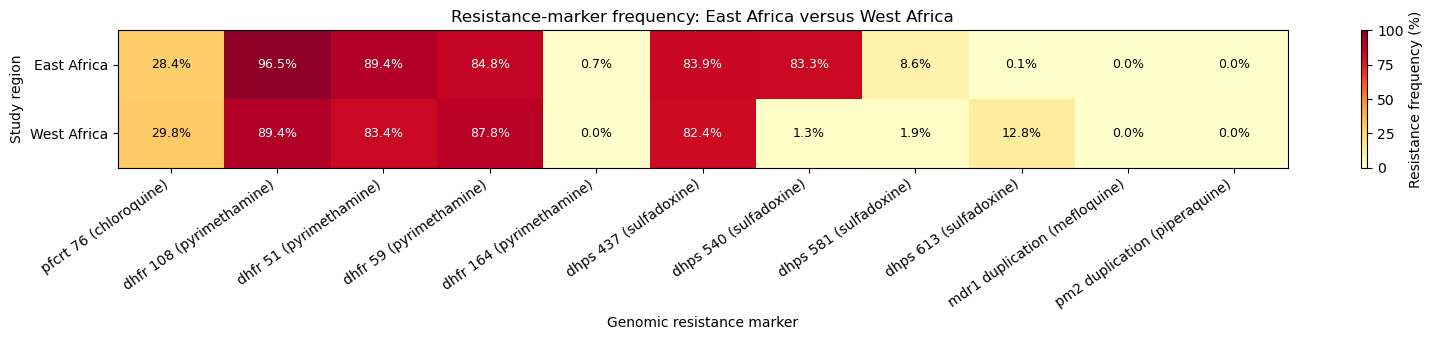

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Markers to show in the final East-versus-West figure.
# kelch13 is excluded because it has too little usable data.
plot_markers = [
    "crt_76[K]",
    "dhfr_108[S]",
    "dhfr_51[N]_assoc",
    "dhfr_59[C]_assoc",
    "dhfr_164[I]_assoc",
    "dhps_437[G]",
    "dhps_540[K]_assoc",
    "dhps_581[A]_assoc",
    "dhps_613[A]_assoc",
    "mdr1_dup_call",
    "pm2_dup_call"
]

plot_marker_names = [marker_labels[marker] for marker in plot_markers]

# Keep only the two study regions
focus_regions = ["East Africa", "West Africa"]

east_west_table = regional_frequency_table.loc[
    focus_regions,
    plot_marker_names
]

# Create the heatmap
fig, ax = plt.subplots(figsize=(16, 3.5))

image = ax.imshow(
    east_west_table,
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    aspect="auto"
)

ax.set_xticks(range(len(east_west_table.columns)))
ax.set_xticklabels(east_west_table.columns, rotation=35, ha="right")

ax.set_yticks(range(len(east_west_table.index)))
ax.set_yticklabels(east_west_table.index)

ax.set_title("Resistance-marker frequency: East Africa versus West Africa")
ax.set_xlabel("Genomic resistance marker")
ax.set_ylabel("Study region")

# Write percentages inside the coloured squares
for row_number in range(len(east_west_table.index)):
    for column_number in range(len(east_west_table.columns)):
        value = east_west_table.iloc[row_number, column_number]

        if pd.notna(value):
            text_colour = "white" if value >= 60 else "black"

            ax.text(
                column_number,
                row_number,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color=text_colour,
                fontsize=9
            )

colourbar = fig.colorbar(image, ax=ax)
colourbar.set_label("Resistance frequency (%)")

plt.tight_layout()
plt.savefig("objective2_east_vs_west_heatmap.png", dpi=300)
plt.show()

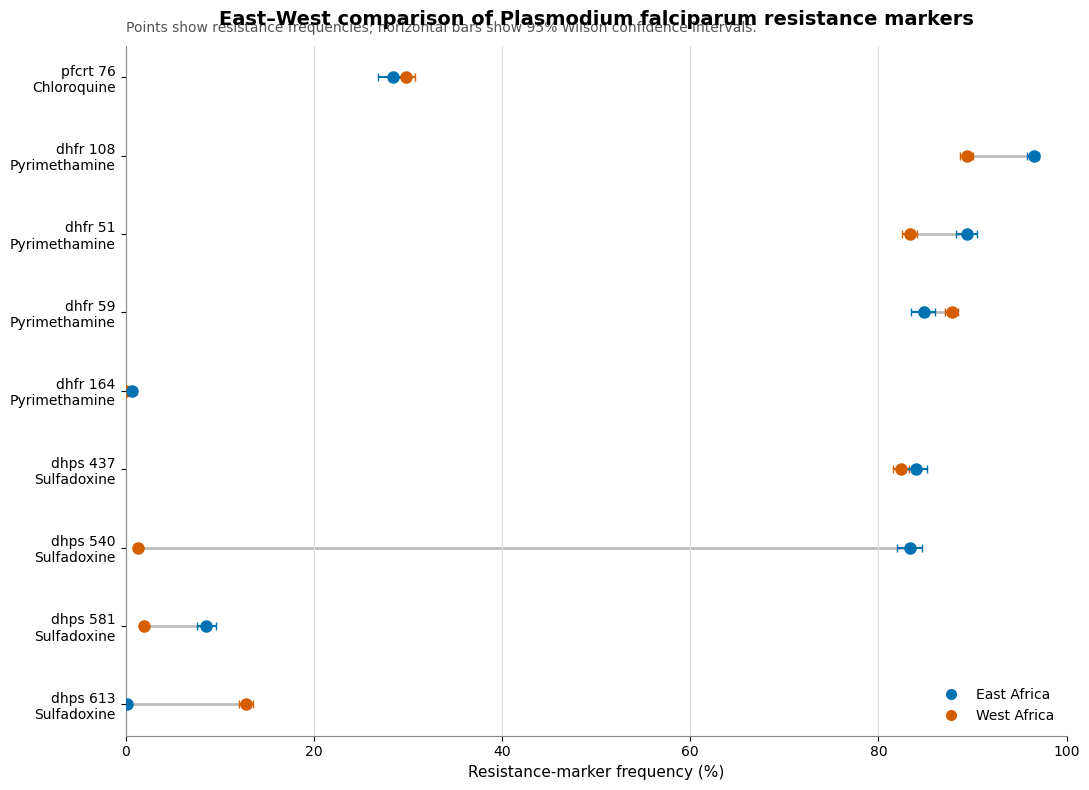

In [26]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math

# Markers suitable for the main scientific comparison figure
main_markers = [
    "pfcrt 76 (chloroquine)",
    "dhfr 108 (pyrimethamine)",
    "dhfr 51 (pyrimethamine)",
    "dhfr 59 (pyrimethamine)",
    "dhfr 164 (pyrimethamine)",
    "dhps 437 (sulfadoxine)",
    "dhps 540 (sulfadoxine)",
    "dhps 581 (sulfadoxine)",
    "dhps 613 (sulfadoxine)"
]

# Short, readable labels for the left side of the figure
short_labels = {
    "pfcrt 76 (chloroquine)": "pfcrt 76\nChloroquine",
    "dhfr 108 (pyrimethamine)": "dhfr 108\nPyrimethamine",
    "dhfr 51 (pyrimethamine)": "dhfr 51\nPyrimethamine",
    "dhfr 59 (pyrimethamine)": "dhfr 59\nPyrimethamine",
    "dhfr 164 (pyrimethamine)": "dhfr 164\nPyrimethamine",
    "dhps 437 (sulfadoxine)": "dhps 437\nSulfadoxine",
    "dhps 540 (sulfadoxine)": "dhps 540\nSulfadoxine",
    "dhps 581 (sulfadoxine)": "dhps 581\nSulfadoxine",
    "dhps 613 (sulfadoxine)": "dhps 613\nSulfadoxine"
}

# Function to calculate a 95% Wilson confidence interval
def wilson_interval(resistant, total, z=1.96):
    proportion = resistant / total
    denominator = 1 + (z**2 / total)

    centre = (proportion + z**2 / (2 * total)) / denominator

    margin = (
        z * math.sqrt(
            (proportion * (1 - proportion) / total) +
            (z**2 / (4 * total**2))
        )
    ) / denominator

    return (centre - margin) * 100, (centre + margin) * 100


# Prepare one row for every marker in East and West Africa
comparison_data = regional_table[
    (regional_table["Subregion"].isin(["East Africa", "West Africa"])) &
    (regional_table["Marker"].isin(main_markers))
].copy()

# Publication-style colours that are also colour-blind friendly
east_colour = "#0072B2"
west_colour = "#D55E00"
line_colour = "#BDBDBD"

fig, ax = plt.subplots(figsize=(11, 8))

for position, marker in enumerate(main_markers):

    east = comparison_data[
        (comparison_data["Subregion"] == "East Africa") &
        (comparison_data["Marker"] == marker)
    ].iloc[0]

    west = comparison_data[
        (comparison_data["Subregion"] == "West Africa") &
        (comparison_data["Marker"] == marker)
    ].iloc[0]

    # Frequencies
    east_frequency = east["Resistance frequency (%)"]
    west_frequency = west["Resistance frequency (%)"]

    # 95% confidence intervals
    east_low, east_high = wilson_interval(
        east["Resistant"],
        east["Callable samples"]
    )

    west_low, west_high = wilson_interval(
        west["Resistant"],
        west["Callable samples"]
    )

    # Connect East and West values for the same marker
    ax.plot(
        [west_frequency, east_frequency],
        [position, position],
        color=line_colour,
        linewidth=2,
        zorder=1
    )

    # West Africa estimate and uncertainty
    ax.errorbar(
        west_frequency,
        position,
        xerr=[[west_frequency - west_low], [west_high - west_frequency]],
        fmt="o",
        color=west_colour,
        markersize=8,
        capsize=3,
        zorder=3
    )

    # East Africa estimate and uncertainty
    ax.errorbar(
        east_frequency,
        position,
        xerr=[[east_frequency - east_low], [east_high - east_frequency]],
        fmt="o",
        color=east_colour,
        markersize=8,
        capsize=3,
        zorder=3
    )

# Figure formatting
ax.set_yticks(range(len(main_markers)))
ax.set_yticklabels([short_labels[marker] for marker in main_markers], fontsize=10)

ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 20))
ax.set_xlabel("Resistance-marker frequency (%)", fontsize=11)

ax.set_title(
    "East–West comparison of Plasmodium falciparum resistance markers",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.text(
    0,
    1.02,
    "Points show resistance frequencies; horizontal bars show 95% Wilson confidence intervals.",
    transform=ax.transAxes,
    fontsize=10,
    color="#555555"
)

ax.grid(axis="x", color="#DDDDDD", linewidth=0.8)
ax.grid(axis="y", visible=False)

# Put the first marker at the top
ax.invert_yaxis()

# Clean figure borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#888888")
ax.spines["bottom"].set_color("#888888")

# Legend
legend_items = [
    Line2D([0], [0], marker="o", color="w", label="East Africa",
           markerfacecolor=east_colour, markersize=9),
    Line2D([0], [0], marker="o", color="w", label="West Africa",
           markerfacecolor=west_colour, markersize=9)
]

ax.legend(handles=legend_items, loc="lower right", frameon=False)

plt.tight_layout()

# Save a high-quality image for your report or slides
plt.savefig(
    "objective2_east_vs_west_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

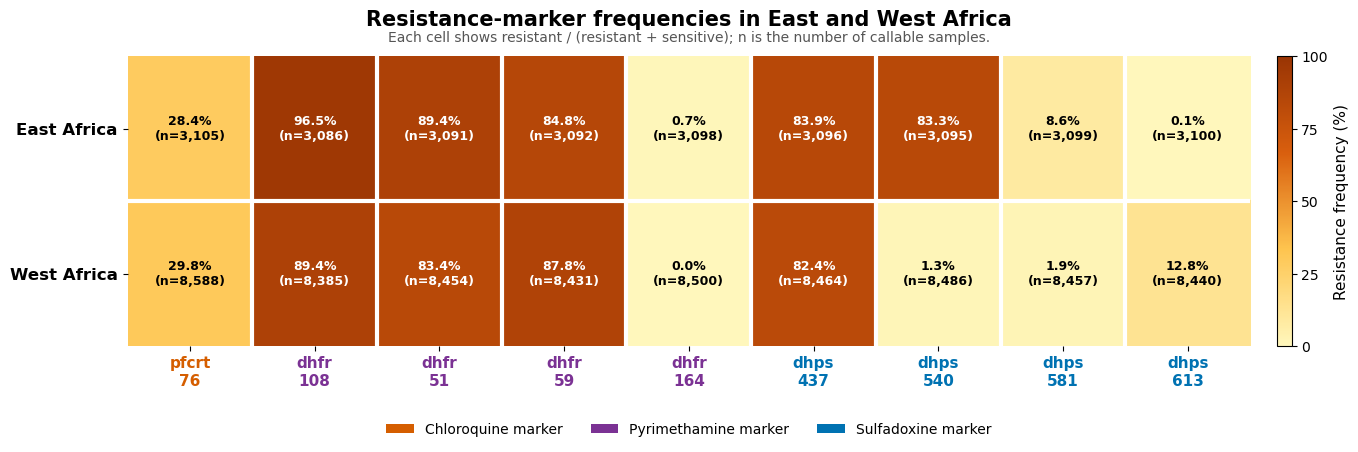

Note: kelch13 was excluded because it had only one callable sample. mdr1 and pm2 duplication calls were excluded from the main figure because many calls were classified as rare.


In [27]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

# Markers used in the main East-versus-West presentation figure
heatmap_markers = [
    "pfcrt 76 (chloroquine)",
    "dhfr 108 (pyrimethamine)",
    "dhfr 51 (pyrimethamine)",
    "dhfr 59 (pyrimethamine)",
    "dhfr 164 (pyrimethamine)",
    "dhps 437 (sulfadoxine)",
    "dhps 540 (sulfadoxine)",
    "dhps 581 (sulfadoxine)",
    "dhps 613 (sulfadoxine)"
]

# Short labels that fit neatly under the heatmap
short_heatmap_labels = [
    "pfcrt\n76",
    "dhfr\n108",
    "dhfr\n51",
    "dhfr\n59",
    "dhfr\n164",
    "dhps\n437",
    "dhps\n540",
    "dhps\n581",
    "dhps\n613"
]

# Drug class for each marker; used to colour the marker names
drug_groups = [
    "Chloroquine",
    "Pyrimethamine",
    "Pyrimethamine",
    "Pyrimethamine",
    "Pyrimethamine",
    "Sulfadoxine",
    "Sulfadoxine",
    "Sulfadoxine",
    "Sulfadoxine"
]

drug_colours = {
    "Chloroquine": "#D55E00",
    "Pyrimethamine": "#7B3294",
    "Sulfadoxine": "#0072B2"
}

# -------------------------------------------------------------------
# PART 1: Create a clean presentation table
# -------------------------------------------------------------------
table_rows = []

for marker in heatmap_markers:
    east = regional_table[
        (regional_table["Subregion"] == "East Africa") &
        (regional_table["Marker"] == marker)
    ].iloc[0]

    west = regional_table[
        (regional_table["Subregion"] == "West Africa") &
        (regional_table["Marker"] == marker)
    ].iloc[0]

    east_frequency = east["Resistance frequency (%)"]
    west_frequency = west["Resistance frequency (%)"]

    table_rows.append({
        "Marker": marker,
        "East Africa": f"{east_frequency:.1f}% (n={int(east['Callable samples']):,})",
        "West Africa": f"{west_frequency:.1f}% (n={int(west['Callable samples']):,})",
        "Difference: East − West (percentage points)": round(
            east_frequency - west_frequency, 1
        )
    })

east_west_presentation_table = pd.DataFrame(table_rows)

# Display the table in the notebook
east_west_presentation_table

# Save the table as a CSV file
east_west_presentation_table.to_csv(
    "objective2_east_vs_west_results_table.csv",
    index=False
)

# -------------------------------------------------------------------
# PART 2: Create the improved heatmap
# -------------------------------------------------------------------
heatmap_frequency = (
    regional_table[
        (regional_table["Subregion"].isin(["East Africa", "West Africa"])) &
        (regional_table["Marker"].isin(heatmap_markers))
    ]
    .pivot(
        index="Subregion",
        columns="Marker",
        values="Resistance frequency (%)"
    )
    .reindex(index=["East Africa", "West Africa"], columns=heatmap_markers)
)

heatmap_sample_size = (
    regional_table[
        (regional_table["Subregion"].isin(["East Africa", "West Africa"])) &
        (regional_table["Marker"].isin(heatmap_markers))
    ]
    .pivot(
        index="Subregion",
        columns="Marker",
        values="Callable samples"
    )
    .reindex(index=["East Africa", "West Africa"], columns=heatmap_markers)
)

# Professional colour scale: pale yellow = low, dark red = high
cmap = LinearSegmentedColormap.from_list(
    "scientific_yellow_red",
    ["#FFF7BC", "#FEC44F", "#D95F0E", "#993404"]
)

fig, ax = plt.subplots(figsize=(15, 4.8))

image = ax.imshow(
    heatmap_frequency,
    cmap=cmap,
    vmin=0,
    vmax=100,
    aspect="auto"
)

# Add exact frequency and usable sample count in every square
for row in range(len(heatmap_frequency.index)):
    for column in range(len(heatmap_frequency.columns)):
        frequency = heatmap_frequency.iloc[row, column]
        sample_size = heatmap_sample_size.iloc[row, column]

        text_colour = "white" if frequency >= 60 else "black"

        ax.text(
            column,
            row,
            f"{frequency:.1f}%\n(n={int(sample_size):,})",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color=text_colour
        )

# Labels
ax.set_xticks(range(len(short_heatmap_labels)))
ax.set_xticklabels(short_heatmap_labels, fontsize=11, fontweight="bold")

ax.set_yticks([0, 1])
ax.set_yticklabels(["East Africa", "West Africa"], fontsize=12, fontweight="bold")

# Colour each marker name by the drug it represents
for label, group in zip(ax.get_xticklabels(), drug_groups):
    label.set_color(drug_colours[group])

# White grid lines between squares
ax.set_xticks([number - 0.5 for number in range(1, len(heatmap_markers))], minor=True)
ax.set_yticks([0.5], minor=True)

ax.grid(which="minor", color="white", linewidth=3)
ax.tick_params(which="minor", bottom=False, left=False)

# Title and subtitle
ax.set_title(
    "Resistance-marker frequencies in East and West Africa",
    fontsize=15,
    fontweight="bold",
    pad=22
)

ax.text(
    0.5,
    1.05,
    "Each cell shows resistant / (resistant + sensitive); n is the number of callable samples.",
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    color="#555555"
)

# Colour scale
colourbar = fig.colorbar(image, ax=ax, pad=0.02)
colourbar.set_label("Resistance frequency (%)", fontsize=11)
colourbar.set_ticks([0, 25, 50, 75, 100])

# Drug-class legend
legend_items = [
    Patch(facecolor=drug_colours["Chloroquine"], label="Chloroquine marker"),
    Patch(facecolor=drug_colours["Pyrimethamine"], label="Pyrimethamine marker"),
    Patch(facecolor=drug_colours["Sulfadoxine"], label="Sulfadoxine marker")
]

ax.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False
)

# Clean borders and save
ax.spines[:].set_visible(False)

plt.tight_layout()

plt.savefig(
    "objective2_east_vs_west_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Note: kelch13 was excluded because it had only one callable sample. "
    "mdr1 and pm2 duplication calls were excluded from the main figure because "
    "many calls were classified as rare."
)

In [28]:
import os

print(
    os.path.exists("objective2_east_vs_west_results_table.csv")
)

True


In [30]:
# Original genotype-column names used by Python
trend_marker_columns = [
    "crt_76[K]",
    "dhfr_108[S]",
    "dhfr_51[N]_assoc",
    "dhfr_59[C]_assoc",
    "dhfr_164[I]_assoc",
    "dhps_437[G]",
    "dhps_540[K]_assoc",
    "dhps_581[A]_assoc",
    "dhps_613[A]_assoc"
]

# Readable names used in the final table and figures
trend_marker_labels = {
    "crt_76[K]": "pfcrt 76 (chloroquine)",
    "dhfr_108[S]": "dhfr 108 (pyrimethamine)",
    "dhfr_51[N]_assoc": "dhfr 51 (pyrimethamine)",
    "dhfr_59[C]_assoc": "dhfr 59 (pyrimethamine)",
    "dhfr_164[I]_assoc": "dhfr 164 (pyrimethamine)",
    "dhps_437[G]": "dhps 437 (sulfadoxine)",
    "dhps_540[K]_assoc": "dhps 540 (sulfadoxine)",
    "dhps_581[A]_assoc": "dhps 581 (sulfadoxine)",
    "dhps_613[A]_assoc": "dhps 613 (sulfadoxine)"
}

# Keep only five-year periods with enough total samples
usable_periods = period_counts[
    period_counts["Use for trend analysis?"] == True
].index.tolist()

# Keep only East Africa, West Africa, and usable time periods
time_data = africa_time[
    (africa_time["subregion"].isin(["East Africa", "West Africa"])) &
    (africa_time["five_year_period"].isin(usable_periods))
].copy()

# Calculate: region × five-year period × marker
trend_results = []

for (region, period), group in time_data.groupby(
    ["subregion", "five_year_period"]
):
    for marker in trend_marker_columns:

        calls = group[marker].fillna("Missing").value_counts()

        resistant = calls.get("Resistant", 0)
        sensitive = calls.get("Sensitive", 0)
        callable_samples = resistant + sensitive

        if callable_samples >= 30:
            frequency = resistant / callable_samples * 100
        else:
            frequency = None

        trend_results.append({
            "Region": region,
            "Five-year period": period,
            "Marker": trend_marker_labels[marker],
            "Resistant": resistant,
            "Sensitive": sensitive,
            "Callable samples": callable_samples,
            "Resistance frequency (%)": frequency
        })

trend_table = pd.DataFrame(trend_results)

# Save the complete time-analysis table
trend_table.to_csv(
    "objective2_east_west_time_trends.csv",
    index=False
)

print("Time-trend table saved successfully.")
print("Number of rows:", len(trend_table))

trend_table.head(12)

Time-trend table saved successfully.
Number of rows: 108


,Region,Five-year period,Marker,Resistant,Sensitive,Callable samples,Resistance frequency (%)
0,East Africa,1995–1999,pfcrt 76 (chloroquine),214,45,259,82.625483
1,East Africa,1995–1999,dhfr 108 (pyrimethamine),202,57,259,77.992278
2,East Africa,1995–1999,dhfr 51 (pyrimethamine),143,116,259,55.212355
3,East Africa,1995–1999,dhfr 59 (pyrimethamine),157,102,259,60.617761
4,East Africa,1995–1999,dhfr 164 (pyrimethamine),0,259,259,0.000000
5,East Africa,1995–1999,dhps 437 (sulfadoxine),67,192,259,25.868726
6,East Africa,1995–1999,dhps 540 (sulfadoxine),65,194,259,25.096525
7,East Africa,1995–1999,dhps 581 (sulfadoxine),0,259,259,0.000000
8,East Africa,1995–1999,dhps 613 (sulfadoxine),0,259,259,0.000000
9,East Africa,2000–2004,pfcrt 76 (chloroquine),74,65,139,53.237410


C:\Users\hp\AppData\Local\Temp\ipykernel_23932\771881015.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.94, 0.88])


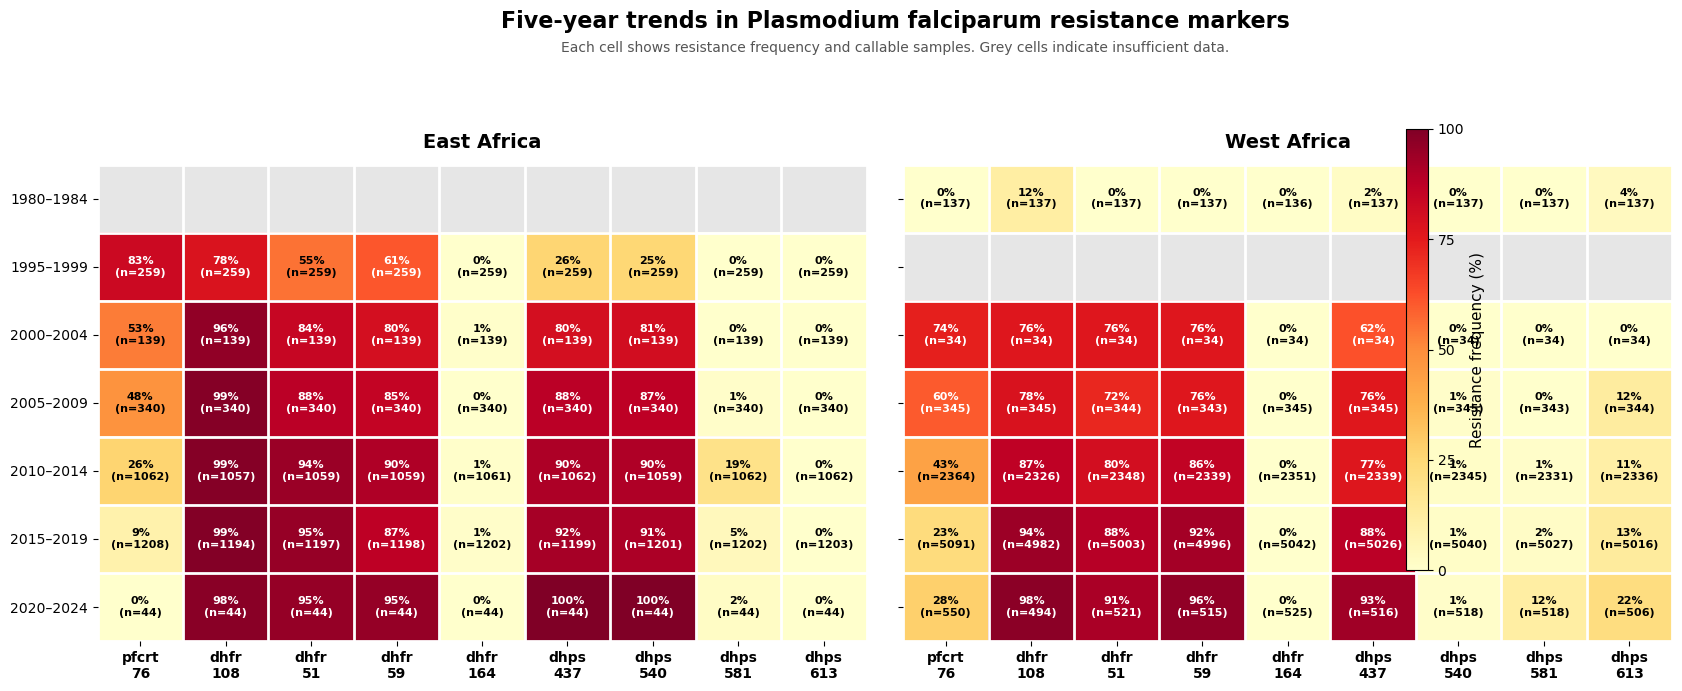

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Order of markers in the time heatmaps
time_marker_order = [
    "pfcrt 76 (chloroquine)",
    "dhfr 108 (pyrimethamine)",
    "dhfr 51 (pyrimethamine)",
    "dhfr 59 (pyrimethamine)",
    "dhfr 164 (pyrimethamine)",
    "dhps 437 (sulfadoxine)",
    "dhps 540 (sulfadoxine)",
    "dhps 581 (sulfadoxine)",
    "dhps 613 (sulfadoxine)"
]

# Short labels so the figure remains easy to read
time_marker_labels = [
    "pfcrt\n76",
    "dhfr\n108",
    "dhfr\n51",
    "dhfr\n59",
    "dhfr\n164",
    "dhps\n437",
    "dhps\n540",
    "dhps\n581",
    "dhps\n613"
]

# Keep only time periods actually represented in East or West Africa
period_order = sorted(trend_table["Five-year period"].unique())

# Professional frequency colour scale
cmap = plt.colormaps["YlOrRd"].copy()
cmap.set_bad("#E6E6E6")  # grey = insufficient data

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    sharey=True
)

for ax, region in zip(axes, ["East Africa", "West Africa"]):

    region_data = trend_table[
        trend_table["Region"] == region
    ].copy()

    # Frequency matrix: rows are periods, columns are markers
    frequency_matrix = region_data.pivot(
        index="Five-year period",
        columns="Marker",
        values="Resistance frequency (%)"
    ).reindex(
        index=period_order,
        columns=time_marker_order
    )

    # Sample-size matrix, used for the n= labels inside each cell
    sample_matrix = region_data.pivot(
        index="Five-year period",
        columns="Marker",
        values="Callable samples"
    ).reindex(
        index=period_order,
        columns=time_marker_order
    )

    image = ax.imshow(
        frequency_matrix,
        cmap=cmap,
        vmin=0,
        vmax=100,
        aspect="auto"
    )

    # Write percentage and callable sample size inside every available cell
    for row in range(len(frequency_matrix.index)):
        for column in range(len(frequency_matrix.columns)):

            frequency = frequency_matrix.iloc[row, column]
            sample_size = sample_matrix.iloc[row, column]

            if pd.notna(frequency):
                text_colour = "white" if frequency >= 60 else "black"

                ax.text(
                    column,
                    row,
                    f"{frequency:.0f}%\n(n={int(sample_size)})",
                    ha="center",
                    va="center",
                    fontsize=8,
                    fontweight="bold",
                    color=text_colour
                )

    # Axis labels
    ax.set_xticks(range(len(time_marker_labels)))
    ax.set_xticklabels(
        time_marker_labels,
        fontsize=10,
        fontweight="bold"
    )

    ax.set_yticks(range(len(period_order)))
    ax.set_yticklabels(period_order, fontsize=10)

    ax.set_title(region, fontsize=14, fontweight="bold", pad=12)

    # White lines separating heatmap cells
    ax.set_xticks(
        np.arange(-0.5, len(time_marker_labels), 1),
        minor=True
    )
    ax.set_yticks(
        np.arange(-0.5, len(period_order), 1),
        minor=True
    )

    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Clean borders
    ax.spines[:].set_visible(False)

# Main title
fig.suptitle(
    "Five-year trends in Plasmodium falciparum resistance markers",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.92,
    "Each cell shows resistance frequency and callable samples. Grey cells indicate insufficient data.",
    ha="center",
    fontsize=10,
    color="#555555"
)

# One shared colour scale
colourbar = fig.colorbar(
    image,
    ax=axes,
    shrink=0.82,
    pad=0.02
)

colourbar.set_label(
    "Resistance frequency (%)",
    fontsize=11
)

colourbar.set_ticks([0, 25, 50, 75, 100])

plt.tight_layout(rect=[0, 0, 0.94, 0.88])

plt.savefig(
    "objective2_east_west_time_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

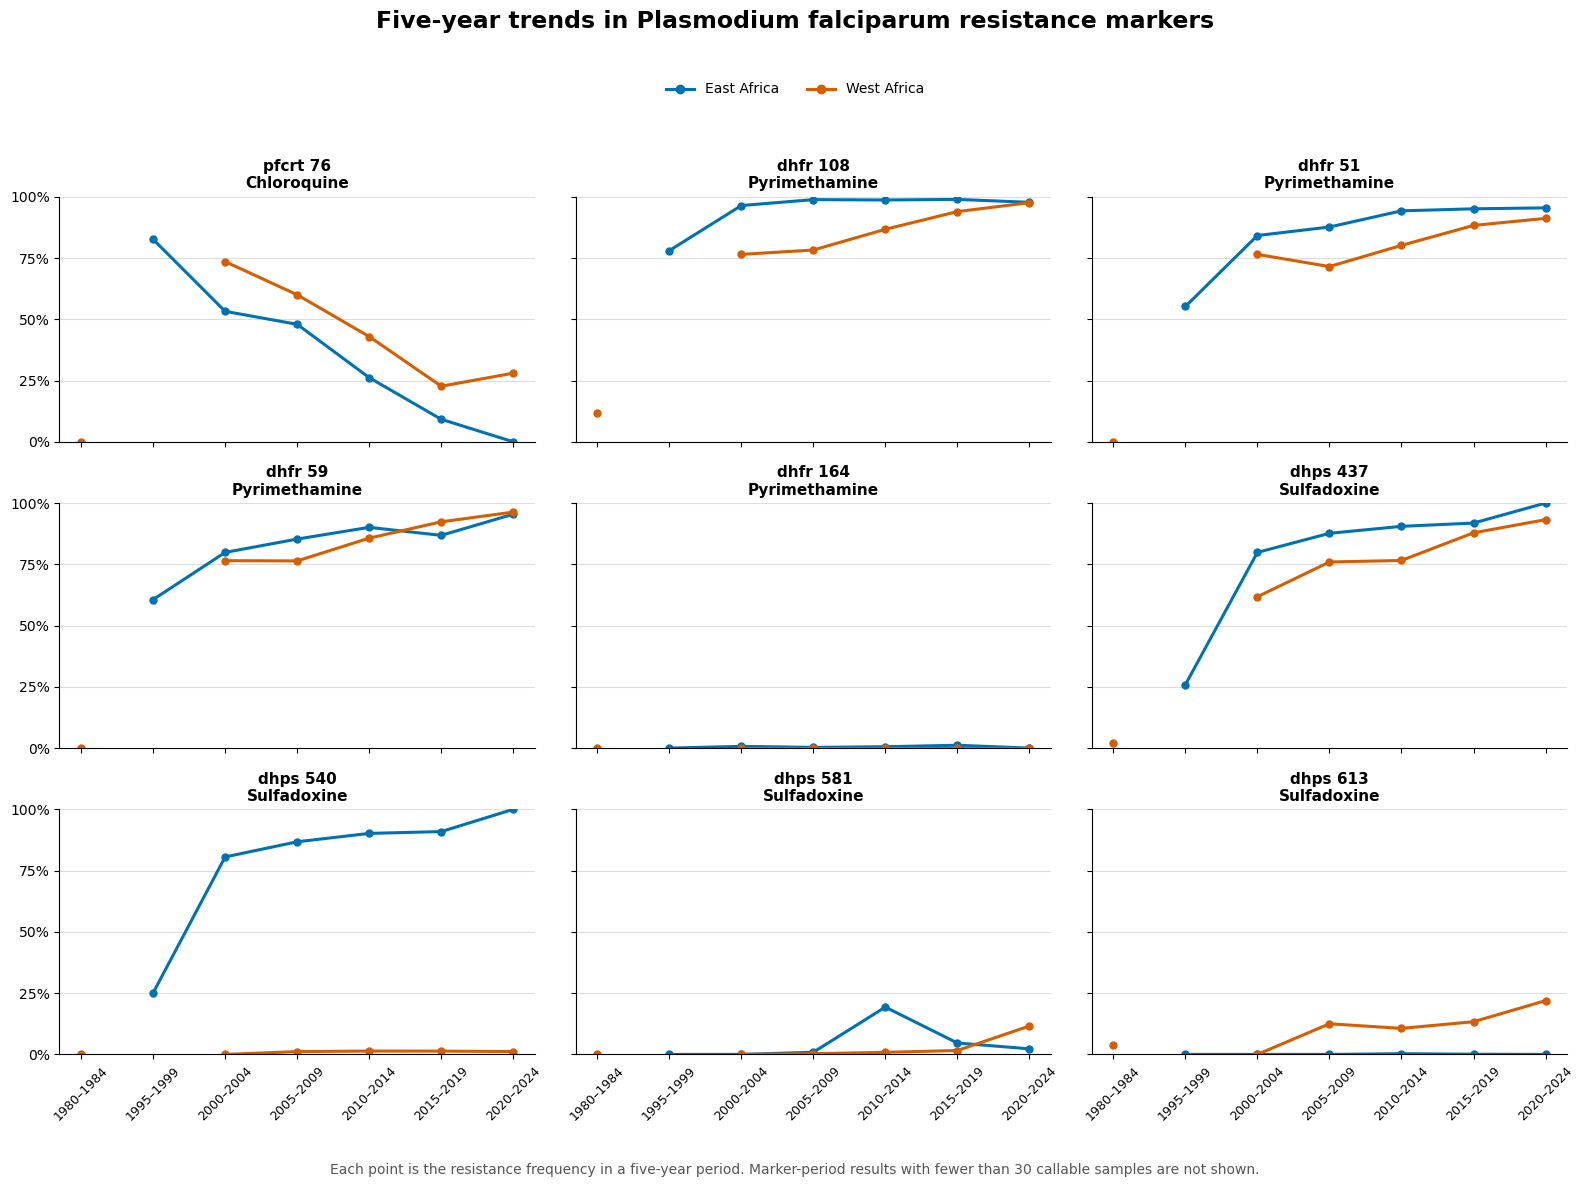

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Marker order for the nine small time-trend charts
time_marker_order = [
    "pfcrt 76 (chloroquine)",
    "dhfr 108 (pyrimethamine)",
    "dhfr 51 (pyrimethamine)",
    "dhfr 59 (pyrimethamine)",
    "dhfr 164 (pyrimethamine)",
    "dhps 437 (sulfadoxine)",
    "dhps 540 (sulfadoxine)",
    "dhps 581 (sulfadoxine)",
    "dhps 613 (sulfadoxine)"
]

# Short titles for the individual charts
short_titles = {
    "pfcrt 76 (chloroquine)": "pfcrt 76\nChloroquine",
    "dhfr 108 (pyrimethamine)": "dhfr 108\nPyrimethamine",
    "dhfr 51 (pyrimethamine)": "dhfr 51\nPyrimethamine",
    "dhfr 59 (pyrimethamine)": "dhfr 59\nPyrimethamine",
    "dhfr 164 (pyrimethamine)": "dhfr 164\nPyrimethamine",
    "dhps 437 (sulfadoxine)": "dhps 437\nSulfadoxine",
    "dhps 540 (sulfadoxine)": "dhps 540\nSulfadoxine",
    "dhps 581 (sulfadoxine)": "dhps 581\nSulfadoxine",
    "dhps 613 (sulfadoxine)": "dhps 613\nSulfadoxine"
}

# Put periods in chronological order
period_order = sorted(
    trend_table["Five-year period"].unique(),
    key=lambda period: int(period[:4])
)

east_colour = "#0072B2"
west_colour = "#D55E00"

# Create 9 panels: 3 rows × 3 columns
fig, axes = plt.subplots(
    3,
    3,
    figsize=(16, 12),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, marker in zip(axes, time_marker_order):

    marker_data = trend_table[
        trend_table["Marker"] == marker
    ]

    for region, colour in [
        ("East Africa", east_colour),
        ("West Africa", west_colour)
    ]:

        region_data = marker_data[
            marker_data["Region"] == region
        ].set_index("Five-year period")

        # Reorder periods correctly; missing results become gaps in the line
        frequencies = region_data.reindex(
            period_order
        )["Resistance frequency (%)"]

        ax.plot(
            period_order,
            frequencies,
            marker="o",
            markersize=5,
            linewidth=2.2,
            color=colour
        )

    ax.set_title(
        short_titles[marker],
        fontsize=11,
        fontweight="bold"
    )

    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])

    ax.grid(
        axis="y",
        color="#DDDDDD",
        linewidth=0.8
    )

    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Rotate year labels on the bottom row
for ax in axes[-3:]:
    ax.tick_params(
        axis="x",
        rotation=45,
        labelsize=9
    )

# Add one legend for the whole figure
legend_items = [
    Line2D(
        [0], [0],
        color=east_colour,
        marker="o",
        linewidth=2.2,
        label="East Africa"
    ),
    Line2D(
        [0], [0],
        color=west_colour,
        marker="o",
        linewidth=2.2,
        label="West Africa"
    )
]

fig.legend(
    handles=legend_items,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.93)
)

fig.suptitle(
    "Five-year trends in Plasmodium falciparum resistance markers",
    fontsize=17,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.01,
    "Each point is the resistance frequency in a five-year period. "
    "Marker-period results with fewer than 30 callable samples are not shown.",
    ha="center",
    fontsize=10,
    color="#555555"
)

plt.tight_layout(
    rect=[0, 0.04, 1, 0.90]
)

plt.savefig(
    "objective2_east_west_time_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
import os

print(os.path.exists("objective2_east_west_time_trends.csv"))

True
